In [2]:
# mount google drive and set up paths
from google.colab import drive
import sys

drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive')

Mounted at /content/drive


In [3]:
from rich.traceback import install
install()

import os
from pathlib import Path
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import cv2
import subprocess
import tempfile
from skimage import io
from setup_helper import download_repos_and_setup, DRIVE_BASE, SAM_REPO, SAM_CHECKPOINT, LIGHTGLUE_REPO, SWINIR_REPO, SWINIR_MODEL, SWINIR_MODEL_ZOO, INPUT_DIR, show_anns, show_image, show_mask_over_image, plot_masks, plot_one_mask, swinir_upscale

In [4]:
download_repos_and_setup() # run just once

SAM repo found on Drive, skipping clone.
SAM checkpoint found on Drive, skipping download.
LightGlue found on Drive, skipping clone.
SwinIR repo found on Drive, skipping clone.
SwinIR model found on Drive, skipping download.


In [5]:
from lightglue import LightGlue, SuperPoint, DISK
from lightglue.utils import load_image, rbd, ImagePreprocessor
from lightglue.superpoint import simple_nms, top_k_keypoints, sample_descriptors
from kornia.color import rgb_to_grayscale
from lightglue import viz2d

In [6]:
class BatchedSuperPoint(SuperPoint):
    def __init__(self, **conf):
        super().__init__(**conf)

    def forward(self, data: dict) -> dict:
        image = data["image"] # Original input
        device = image.device
        b, _, h, w = image.shape

        # 1. Preprocessing and Metadata inside no_grad
        with torch.no_grad():
            image_sizes = torch.tensor([w, h], device=device).float().repeat(b, 1)
            preprocessor = ImagePreprocessor(**self.preprocess_conf)
            # 'img' is the resized/normalized version, 'scales' are the ratios
            img, scales = preprocessor(image)

        # 2. Use 'img' (the preprocessed version) for the CNN layers
        x = self.relu(self.conv1a(img))
        x = self.relu(self.conv1b(x))
        x = self.pool(x)
        x = self.relu(self.conv2a(x))
        x = self.relu(self.conv2b(x))
        x = self.pool(x)
        x = self.relu(self.conv3a(x))
        x = self.relu(self.conv3b(x))
        x = self.pool(x)
        x = self.relu(self.conv4a(x))
        x = self.relu(self.conv4b(x))

        # Compute the dense keypoint scores
        cPa = self.relu(self.convPa(x))
        scores = self.convPb(cPa)
        scores = torch.nn.functional.softmax(scores, 1)[:, :-1]
        b_proc, _, h_proc, w_proc = scores.shape
        assert b == b_proc # this must always be true
        scores = scores.permute(0, 2, 3, 1).reshape(b_proc, h_proc, w_proc, 8, 8)
        scores = scores.permute(0, 1, 3, 2, 4).reshape(b_proc, h_proc * 8, w_proc * 8)
        scores = simple_nms(scores, self.conf.nms_radius)

        if self.conf.remove_borders:
            pad = self.conf.remove_borders
            scores[:, :pad] = -1
            scores[:, :, :pad] = -1
            scores[:, -pad:] = -1
            scores[:, :, -pad:] = -1

        best_kp = torch.where(scores > self.conf.detection_threshold)
        
        scores = scores[best_kp]
        
        keypoints = [
            torch.stack(best_kp[1:3], dim=-1)[best_kp[0] == i] for i in range(b_proc)
        ]
       
        scores_list = [scores[best_kp[0] == i] for i in range(b_proc)]

        if self.conf.max_num_keypoints is not None:
            keypoints, scores_list = list(
                zip(
                    *[
                        top_k_keypoints(k, s, self.conf.max_num_keypoints)
                        for k, s in zip(keypoints, scores_list)
                    ]
                )
            )

        # scores_list is becomes a tuple of tensors so converting back to list
        scores_list = list(scores_list)

        # Convert (h, w) to (x, y)
        keypoints = [torch.flip(k, [1]).float() for k in keypoints]

        # Compute descriptors
        cDa = self.relu(self.convDa(x))
        descriptors = self.convDb(cDa)
        descriptors = torch.nn.functional.normalize(descriptors, p=2, dim=1)

        descriptors = [
            sample_descriptors(k[None], d[None], 8)[0]
            for k, d in zip(keypoints, descriptors)
        ]
        
        # 3. Final Scaling back to original resolution
        scaled_keypoints = []
        for i in range(b_proc):
            k = (keypoints[i] + 0.5) / scales[None] - 0.5
            scaled_keypoints.append(k)
        
        return {
            "keypoints": scaled_keypoints,
            "keypoint_scores": scores_list,
            "descriptors": [d.transpose(-1, -2).contiguous() for d in descriptors],
            "image_size": image_sizes,
            "scales": scales
        }

torch.set_grad_enabled(False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
extractor = BatchedSuperPoint(max_num_keypoints=1024).eval().to(device)
# load the extractor
# matcher = LightGlue(features="superpoint").eval().to(device)
matcher = LightGlue(
    features="superpoint",
    # depth_confidence=-1,   # disable early stopping
    width_confidence=-1,    # disable pruning
    filter_threshold=0.2,
).eval().to(device)

Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_v1.pth" to /root/.cache/torch/hub/checkpoints/superpoint_v1.pth


100%|██████████| 4.96M/4.96M [00:00<00:00, 113MB/s]


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_lightglue.pth" to /root/.cache/torch/hub/checkpoints/superpoint_lightglue_v0-1_arxiv.pth


100%|██████████| 45.3M/45.3M [00:00<00:00, 107MB/s] 


In [8]:
def batch_superglue_run(extractor, matcher, input_drive_path: str, output_drive_path: str, batch_size: int = 32):

    input_path = Path(input_drive_path)
    output_path = Path(output_drive_path)

    output_path.mkdir(parents=True, exist_ok=True)
    flm_image_paths = sorted(input_path.glob('*.png'))
    tem_image = cv2.imread(INPUT_DIR / 'tem.png', cv2.IMREAD_GRAYSCALE)


    # need to add batch and channel dimension
    # tem_t = torch.from_numpy(tem_image).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
    # feats_tem = extractor({'image': tem_t})

   

    all_results = []

    for i in range(0, len(flm_image_paths), batch_size):

        batch_img_paths = flm_image_paths[i : i + batch_size]
        batch_imgs = [cv2.imread(str(p), cv2.IMREAD_GRAYSCALE) for p in batch_img_paths]

        # Convert list of images to a single 4D BCHW tensor
        flm_batch_t = torch.stack([
            torch.from_numpy(img).float().unsqueeze(0) for img in batch_imgs
        ]).to(device) / 255.0
        
        feats_flm = extractor({'image': flm_batch_t})
        current_batch_len = len(batch_imgs)

        # Create template batch by repeating the image, not the features
        tem_batch_t = torch.from_numpy(tem_image).float().unsqueeze(0).unsqueeze(0).repeat(current_batch_len, 1, 1, 1).to(device) / 255.0
        feats0 = extractor({'image': tem_batch_t})

        # After your replication, verify shapes
       
        # repeat the TEM features to match 'current_batch_len'
        # because LightGlue expects a 1-to-1 pair for every item in the batch
        # feats0 = {}
        
        # for k, v in feats_tem.items():
        #     print(k, type(v))
        #     if isinstance(v, list):
        #         # Repeat the list elements
        #         feats0[k] = v * current_batch_len
        #     else:
        #         # Repeat the tensor along the batch dimension
        #         repeat_dims = [1] * v.ndim
        #         repeat_dims[0] = current_batch_len
        #         feats0[k] = v.repeat(repeat_dims)

        def pad_and_stack(tensor_list, fill_value=0):
            # tensor_list is your list of B tensors (ragged)
            max_len = max([t.shape[0] for t in tensor_list])
            dim = tensor_list[0].shape[-1] if tensor_list[0].ndim > 1 else None
            
            batch_size = len(tensor_list)
            if dim:
                out = tensor_list[0].new_full((batch_size, max_len, dim), fill_value)
            else:
                out = tensor_list[0].new_full((batch_size, max_len), fill_value)
                
            for i, t in enumerate(tensor_list):
                out[i, :len(t)] = t
            return out

        # Prepare input for LightGlue
        lg_input = {
            "image0": {
                "keypoints": pad_and_stack(feats0["keypoints"]),
                "descriptors": pad_and_stack(feats0["descriptors"]),
                "image_size": feats0["image_size"]
            },
            "image1": {
                "keypoints": pad_and_stack(feats_flm["keypoints"]),
                "descriptors": pad_and_stack(feats_flm["descriptors"]),
                "image_size": feats_flm["image_size"]
            }
        }

        # print(lg_input['image0']["image_size"].shape)  # Should be [batch_size, 2]
        # print(lg_input['image0']["keypoints"].shape)   # Should be [batch_size, num_kpts, 2] 
        # print(lg_input['image0']["descriptors"].shape) # Should be [batch_size, num_kpts, 256]

        # breakpoint()
        with torch.no_grad():
            matches_out = matcher(lg_input)

        # Move results to CPU and store
        all_results.append({
            "keypoints0": lg_input["image0"]["keypoints"],
            "keypoints1": lg_input["image1"]["keypoints"],
            "paths": batch_img_paths,
            "matches": matches_out["matches"],
            "scores": matches_out["matching_scores0"].cpu()
        })

        # Clear VRAM for the next batch
        del flm_batch_t, feats_flm, feats0, matches_out

    return all_results

all_results = batch_superglue_run(extractor, matcher, DRIVE_BASE / 'tiles_output', DRIVE_BASE / 'superglue_output', batch_size=4)


In [9]:
keypoints0 = all_results[0]['keypoints0']
keypoints1 = all_results[0]['keypoints1']
matches = all_results[0]['matches']
paths = all_results[0]['paths']

In [10]:
# select the first one in the batch
kpts0 = keypoints0[0]
kpts1 = keypoints1[0]
matches01 = matches[0]

m_kpts0, m_kpts1 = kpts0[matches01[..., 0]], kpts1[matches01[..., 1]]

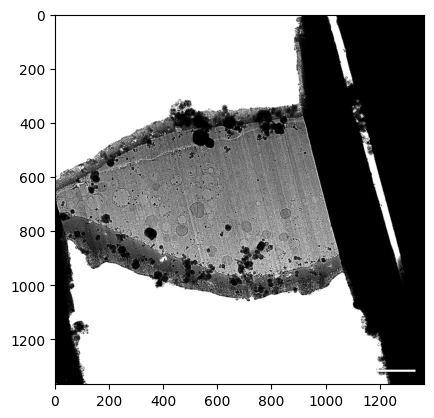

In [11]:
import matplotlib.pyplot as plt
image0 = cv2.imread(INPUT_DIR / 'tem.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(image0, cmap='gray')

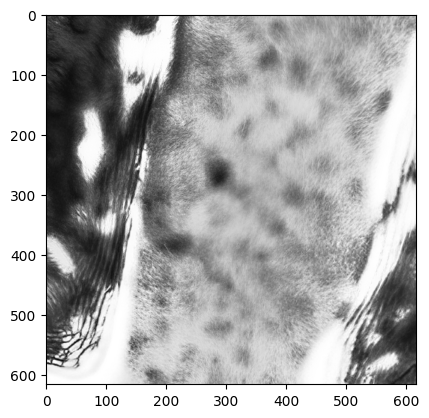

In [12]:
image1 = cv2.imread(paths[0], cv2.IMREAD_GRAYSCALE)
plt.imshow(image1, cmap='gray')

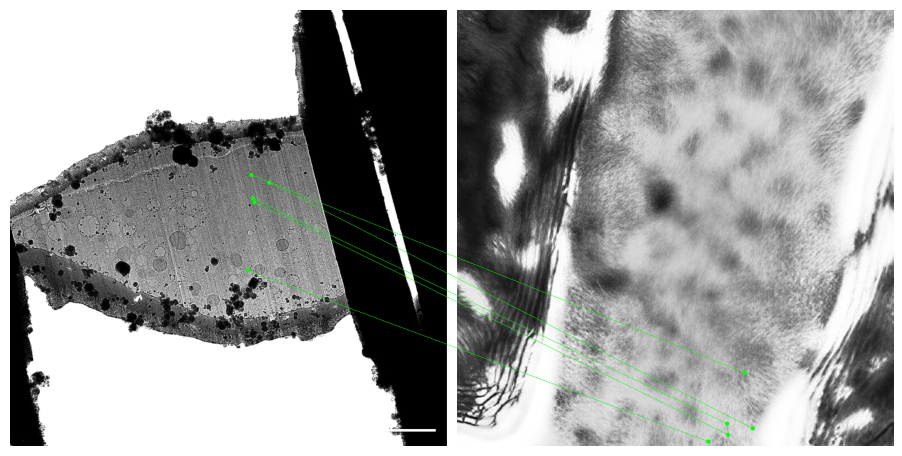

In [13]:
axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.3)